# Introduction to Python

Python is a readable, general-purpose programming language used for scripting, data analysis, scientific computing, machine learning, and many other tasks.

## Learning objectives

By the end of this notebook, you should be able to:

- run Python code in a Jupyter notebook;
- work with variables, built-in types, strings, and collections;
- use conditionals, loops, functions, and comprehensions;
- import modules and handle common errors;
- define a simple class and read or write a file;
- perform basic numerical work with NumPy; and
- create and use an isolated Python environment on Linux or macOS.

## Working in a Jupyter notebook

A notebook contains **Markdown cells** for explanations and **code cells** for executable Python.

- Run the selected cell with **Shift+Enter**.
- The number beside a code cell records when it ran.
- Variables remain available after a cell runs.
- Run cells from top to bottom when reproducing a result.
- If the state becomes confusing, restart the kernel and run all cells again.

In [1]:
print("Hello, TECH 65000!")
2 + 3

Hello, TLI 65000!


5

## Virtual environments on Linux and macOS

The setup in this section covers Linux and macOS. A virtual environment gives a project its own Python interpreter and installed packages. This prevents one project's dependencies from changing another project's setup.

Python provides the built-in `venv` module. Run the commands below in a terminal, not in a Python code cell.

### Linux

~~~bash
python3 -m venv .venv
source .venv/bin/activate
~~~

### macOS

Open the Terminal app, change to your project directory, and run:

~~~bash
python3 -m venv .venv
source .venv/bin/activate
~~~

The creation and activation commands are the same on Linux and macOS.

After activation, update pip and install the tools used by this course:

~~~bash
python -m pip install --upgrade pip
python -m pip install jupyter ipykernel numpy matplotlib
~~~

Register the environment as a selectable Jupyter kernel:

~~~bash
python -m ipykernel install --user --name tli65000 --display-name "Python (TLI 65000)"
~~~

Select **Python (TLI 65000)** as this notebook's kernel. Verify that the environment's Python interpreter is active from the terminal:

~~~bash
python -c "import sys; print(sys.executable)"
~~~

When finished, leave the environment with:

~~~bash
deactivate
~~~

The .venv directory is disposable and should not be committed to Git. Record dependencies in a requirements file so the environment can be recreated. See Python's official [venv documentation](https://docs.python.org/3/library/venv.html) for more details.

## Variables and built-in types

A variable associates a name with a value. Python determines the type at runtime. Common built-in types include integers, floating-point numbers, complex numbers, strings, Boolean values, and the special value None.

Choose descriptive names, use lowercase words separated by underscores, and remember that names are case-sensitive.

In [2]:
course_name = "TECH 65000"    # str
week = 1                     # int
temperature = 22.5           # float
is_ready = True              # bool
missing_value = None         # NoneType

for value in (course_name, week, temperature, is_ready, missing_value):
    print(f"{value!r:12} -> {type(value).__name__}")

'TECH 65000' -> str
1            -> int
22.5         -> float
True         -> bool
None         -> NoneType


## Arithmetic, comparisons, and Boolean logic

Python supports ordinary arithmetic along with comparison and logical operators.

| Operation | Operator |
|---|---|
| Addition, subtraction | +, - |
| Multiplication, division | *, / |
| Integer division, remainder | //, % |
| Exponentiation | ** |
| Comparison | ==, !=, <, <=, >, >= |
| Boolean logic | and, or, not |

A single equals sign assigns a value. Two equals signs test equality.

In [3]:
a = 7
b = 3

print("arithmetic:", a + b, a - b, a * b, a / b)
print("integer operations:", a // b, a % b, a ** b)
print("comparisons:", a > b, a == b)
print("logic:", (a > 0) and (b > 0))

arithmetic: 10 4 21 2.3333333333333335
integer operations: 2 1 343
comparisons: True False
logic: True


## Strings

Strings store text. They can be indexed and sliced like other Python sequences. Useful operations include joining strings, changing case, replacing text, and formatting values with f-strings.

In [4]:
message = "learning Python"

print(message[0])          # First character
print(message[-6:])        # Last six characters
print(message.upper())
print(message.replace("Python", "together"))

student = "Ada"
score = 92.5
print(f"{student}'s score is {score:.1f}%")

l
Python
LEARNING PYTHON
learning together
Ada's score is 92.5%


## Collections

Python's main built-in collections are:

- **list:** ordered and mutable;
- **tuple:** ordered and immutable;
- **dictionary:** mutable key-value pairs; and
- **set:** an unordered collection of unique values.

Indices begin at zero. A slice start:stop includes the start position but excludes the stop position.

In [5]:
measurements = [2.4, 2.7, 2.5, 2.8]
point = (3.0, 4.0)
student = {"name": "Ada", "score": 92}
labels = {"train", "test", "train"}

measurements.append(3.0)
student["passed"] = student["score"] >= 70

print("first two:", measurements[:2])
print("point:", point)
print("student:", student)
print("unique labels:", labels)

first two: [2.4, 2.7]
point: (3.0, 4.0)
student: {'name': 'Ada', 'score': 92, 'passed': True}
unique labels: {'train', 'test'}


## Conditional statements

An if statement selects which block of code runs. Indentation is part of Python's syntax, so use four spaces for each level.

In [6]:
score = 84

if score >= 90:
    letter = "A"
elif score >= 80:
    letter = "B"
elif score >= 70:
    letter = "C"
else:
    letter = "Needs improvement"

print(letter)

B


## Loops

A for loop processes each item in an iterable. A while loop repeats as long as its condition remains true. The built-ins range and enumerate are especially useful in loops.

In [7]:
values = [3, 5, 8]

for index, value in enumerate(values):
    print(f"index {index}: square = {value ** 2}")

countdown = 3
while countdown > 0:
    print(countdown)
    countdown -= 1

index 0: square = 9
index 1: square = 25
index 2: square = 64
3
2
1


## Functions

A function packages reusable behavior. Parameters are inputs, return sends a result back to the caller, and a docstring explains the function. Type hints document expected types but do not automatically enforce them.

In [8]:
def mean(values: list[float]) -> float:
    """Return the arithmetic mean of a nonempty list."""
    return sum(values) / len(values)


def greet(name: str, greeting: str = "Hello") -> str:
    return f"{greeting}, {name}!"


print(mean([2.0, 4.0, 9.0]))
print(greet("Grace"))
print(greet("Linus", greeting="Welcome"))

5.0
Hello, Grace!
Welcome, Linus!


### Scope

Names created inside a function are normally local to that function. Prefer returning results over changing global variables; this makes code easier to test and reuse.

In [9]:
scale = 10

def scaled_square(value: float) -> float:
    local_result = scale * value ** 2
    return local_result

print(scaled_square(3))
# local_result is not available here.

90


## Comprehensions

A comprehension constructs a collection from an iterable in a compact form. Use one when the transformation remains easy to read; otherwise, use a regular loop.

In [10]:
squares = [number ** 2 for number in range(6)]
even_squares = [value for value in squares if value % 2 == 0]
square_lookup = {number: number ** 2 for number in range(4)}

print(squares)
print(even_squares)
print(square_lookup)

[0, 1, 4, 9, 16, 25]
[0, 4, 16]
{0: 0, 1: 1, 2: 4, 3: 9}


## Modules and imports

Modules organize reusable code. Python includes a large standard library, and third-party packages can be installed into the active environment. Import only what you need and avoid wildcard imports.

In [11]:
import math
from statistics import mean as statistics_mean

radius = 2.0
area = math.pi * radius ** 2

print(f"circle area: {area:.3f}")
print("mean:", statistics_mean([1, 4, 7]))

circle area: 12.566
mean: 4


## Exceptions

Python raises an exception when it cannot complete an operation. Read the final line of a traceback first: it identifies the exception type and usually explains the problem. Catch only exceptions you can handle meaningfully.

In [12]:
raw_value = "not a number"

try:
    number = float(raw_value)
except ValueError:
    print(f"{raw_value!r} cannot be converted to a float.")
else:
    print(number)
finally:
    print("Conversion attempt complete.")

'not a number' cannot be converted to a float.
Conversion attempt complete.


## Classes

A class defines a new type that combines data with behavior. An object is an instance of a class. The constructor initializes each object, and methods operate on its data.

In [13]:
class Vector2D:
    """A simple two-dimensional vector."""

    def __init__(self, x: float, y: float) -> None:
        self.x = x
        self.y = y

    def norm(self) -> float:
        return (self.x ** 2 + self.y ** 2) ** 0.5


vector = Vector2D(3.0, 4.0)
print(vector.x, vector.y)
print(vector.norm())

3.0 4.0
5.0


## Files and paths

Use pathlib for operating-system-independent paths. Open text files with an explicit encoding. A with block closes resources automatically, even if an error occurs.

In [14]:
from pathlib import Path
from tempfile import TemporaryDirectory

with TemporaryDirectory() as temporary_folder:
    path = Path(temporary_folder) / "notes.txt"
    path.write_text("first line\nsecond line\n", encoding="utf-8")
    contents = path.read_text(encoding="utf-8")

print(contents)

first line
second line



## NumPy arrays

NumPy provides efficient multidimensional arrays and numerical operations. Unlike a list, an array usually stores values of one data type. Operations can act element by element without an explicit Python loop.

The @ operator performs matrix multiplication; * performs element-wise multiplication.

In [15]:
import numpy as np

vector = np.array([1.0, 2.0, 3.0])
matrix = np.array([
    [1.0, 0.0, 2.0],
    [0.0, 1.0, -1.0],
])

print("element-wise square:", vector ** 2)
print("matrix-vector product:", matrix @ vector)
print("Euclidean norm:", np.linalg.norm(vector))

element-wise square: [1. 4. 9.]
matrix-vector product: [ 7. -1.]
Euclidean norm: 3.7416573867739413


## Plotting

Matplotlib is a common plotting library. Label axes and include units when applicable so a figure can be understood without reading the surrounding code.

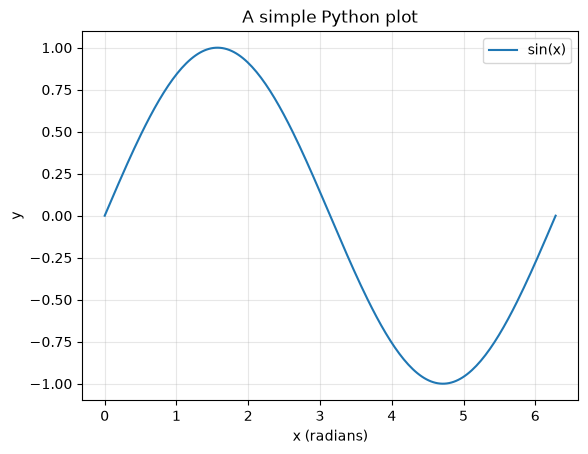

In [16]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y, label="sin(x)")
ax.set(xlabel="x (radians)", ylabel="y", title="A simple Python plot")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Good habits

- Use meaningful names and small, focused functions.
- Keep notebooks reproducible by running cells from top to bottom.
- Write comments that explain **why**, not obvious syntax.
- Read error messages carefully and test small pieces independently.
- Avoid modifying a collection while iterating over it.
- Put reusable code in Python modules rather than copying it between notebooks.
- Record dependencies and never commit secrets or virtual-environment folders.
- Follow the [PEP 8 style guide](https://peps.python.org/pep-0008/) for consistent formatting.

## Practice exercises

1. Write a function that converts a temperature from degrees Fahrenheit to degrees Celsius.
2. Given a list of numbers, use a comprehension to keep only positive values and square them.
3. Count the frequency of each word in a short sentence using a dictionary.
4. Create a 3 by 3 NumPy matrix and multiply it by a compatible vector.
5. Add an add method to Vector2D that returns the sum of two vectors.
6. Create a fresh virtual environment, register it as a Jupyter kernel, and verify which Python executable the notebook uses with sys.executable.